In [ ]:
#13/4/2026 Monday
# t-test is carried out
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.optimizers import Adam
import numpy as np
import os
import tensorflow as tf
import matplotlib.pyplot as plt # plotting training curves
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

In [ ]:
#mount the google drive in colab so that no reupload needed every time colab session ends
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#listing out the directory structure and find the zip file for dog skin disease
os.listdir('/content/drive/MyDrive')

#find the zzip file in the folder that named as fyp_ttest_version8_datasets folder
os.listdir('/content/drive/MyDrive/fyp_ttest_version8_datasets')


['dog_skin_diseases_datasets.zip']

In [ ]:
#extraction of the zip file
import zipfile

zip_path ='/content/drive/MyDrive/fyp_ttest_version8_datasets/dog_skin_diseases_datasets.zip'
extract_path = '/content/drive/MyDrive/fyp_ttest_version8_datasets/dog_skin_diseases_datasets'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
  members = zip_ref.infolist()
  total = len(members)
  for i, member in enumerate(members):
    zip_ref.extract(member,extract_path)
    if i % 100 == 0:
      print(f"Progress: {i}/{total} files ({(i/total)*100:.1f}%)")

print("Extraction completed ")

Progress: 0/4338 files (0.0%)
Progress: 100/4338 files (2.3%)
Progress: 200/4338 files (4.6%)
Progress: 300/4338 files (6.9%)
Progress: 400/4338 files (9.2%)
Progress: 500/4338 files (11.5%)
Progress: 600/4338 files (13.8%)
Progress: 700/4338 files (16.1%)
Progress: 800/4338 files (18.4%)
Progress: 900/4338 files (20.7%)
Progress: 1000/4338 files (23.1%)
Progress: 1100/4338 files (25.4%)
Progress: 1200/4338 files (27.7%)
Progress: 1300/4338 files (30.0%)
Progress: 1400/4338 files (32.3%)
Progress: 1500/4338 files (34.6%)
Progress: 1600/4338 files (36.9%)
Progress: 1700/4338 files (39.2%)
Progress: 1800/4338 files (41.5%)
Progress: 1900/4338 files (43.8%)
Progress: 2000/4338 files (46.1%)
Progress: 2100/4338 files (48.4%)
Progress: 2200/4338 files (50.7%)
Progress: 2300/4338 files (53.0%)
Progress: 2400/4338 files (55.3%)
Progress: 2500/4338 files (57.6%)
Progress: 2600/4338 files (59.9%)
Progress: 2700/4338 files (62.2%)
Progress: 2800/4338 files (64.5%)
Progress: 2900/4338 files (66.9

In [ ]:
#define the train, test and valid folder

train_directory= '/content/drive/MyDrive/fyp_ttest_version8_datasets/dog_skin_diseases_datasets/train'
valid_directory = '/content/drive/MyDrive/fyp_ttest_version8_datasets/dog_skin_diseases_datasets/valid'
test_directory = '/content/drive/MyDrive/fyp_ttest_version8_datasets/dog_skin_diseases_datasets/test'

#check for the folder and verify all 6 classes exists
for split, path in [('train', train_directory),('valid',valid_directory),('test',test_directory)]:
  classes = os.listdir(path)
  print(f"{split}:{len(classes)} classes --> {classes}")


train:6 classes --> ['Dermatitis', 'Fungal_infections', 'Healthy', 'Hypersensitivity', 'demodicosis', 'ringworm']
valid:6 classes --> ['Dermatitis', 'Fungal_infections', 'Healthy', 'Hypersensitivity', 'demodicosis', 'ringworm']
test:6 classes --> ['Dermatitis', 'Fungal_infections', 'Healthy', 'Hypersensitivity', 'demodicosis', 'ringworm']


In [ ]:
#preprocess the image
#applying data augmentation technique
IMAGE_SIZE = (224,224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
      preprocessing_function=preprocess_input, #to expects pixel calue in the range [-1,1]
      rotation_range=20,
      width_shift_range=0.08,
      height_shift_range=0.08,
      shear_range=0.08,
      zoom_range=0.15,
      horizontal_flip=True,
      vertical_flip=True,
      brightness_range=[0.85,1.15],
      fill_mode='nearest'
)

#for validation folder and test dataset, only preprocess it no augmentation
valid_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

#load image from the folder
train_generator = train_datagen.flow_from_directory(train_directory,target_size=IMAGE_SIZE,batch_size=BATCH_SIZE,class_mode='categorical')
valid_generator = valid_test_datagen.flow_from_directory(valid_directory,target_size=IMAGE_SIZE,batch_size=BATCH_SIZE,class_mode='categorical')
test_generator = valid_test_datagen.flow_from_directory(test_directory,target_size=IMAGE_SIZE,batch_size=BATCH_SIZE,class_mode='categorical', shuffle=False) #shuffle is set to false to keep order for evaluation

#verify images in the folder
print("Classes found:", train_generator.class_indices)
print("Train images:", train_generator.samples)
print("Valid images:", valid_generator.samples)
print("Test images:", test_generator.samples)


Found 3022 images belonging to 6 classes.
Found 860 images belonging to 6 classes.
Found 433 images belonging to 6 classes.
Classes found: {'Dermatitis': 0, 'Fungal_infections': 1, 'Healthy': 2, 'Hypersensitivity': 3, 'demodicosis': 4, 'ringworm': 5}
Train images: 3022
Valid images: 860
Test images: 433


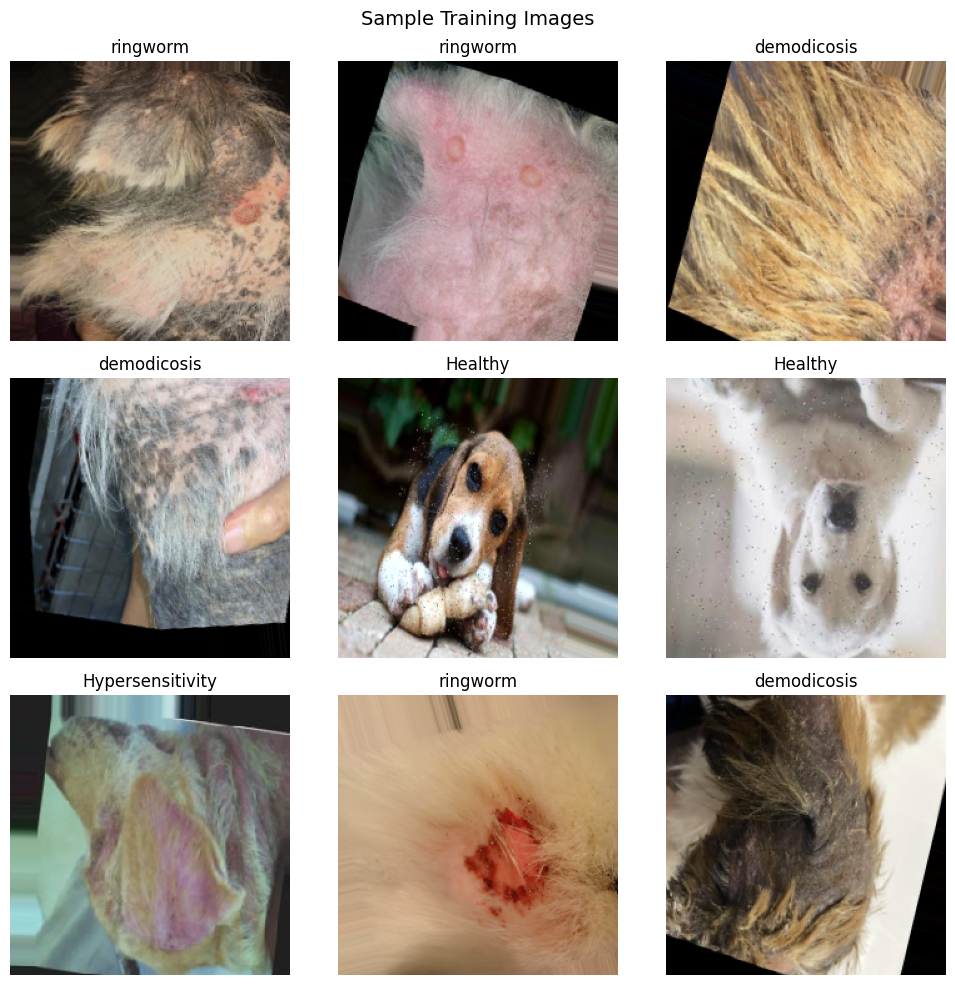

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

#get class names from generator
class_names = list(train_generator.class_indices.keys())

#get one batch of images and lables
images, labels = next(iter(train_generator))

plt.figure(figsize=(10,10))
for i in range(9):
  ax=plt.subplot(3, 3, i+1)
  #reverse the preprocessing back to [0,1] for display
  img=images[i] / 2+0.5
  img=np.clip(img,0,1)
  plt.imshow(img)
  plt.title(class_names[np.argmax(labels[i])])
  plt.axis("off")

plt.suptitle("Sample Training Images", fontsize=14)
plt.tight_layout()
plt.show()


In [ ]:
import random# using the seed training lop
from tensorflow.keras.layers import BatchNormalization
from sklearn.utils.class_weight import compute_class_weight
import json

SEEDS = [42,123, 7, 99, 2024]

initial_val_accuracy = []
finetune_val_accuracy = []

#compute class weights outside the loop
temp_generator = train_datagen.flow_from_directory(train_directory,target_size=IMAGE_SIZE,batch_size= BATCH_SIZE, class_mode = 'categorical')

class_weights = compute_class_weight(
    class_weight = 'balanced',
    classes = np.unique(temp_generator.classes),
    y=temp_generator.classes
)

class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", class_weight_dict)

for seed in SEEDS:
  print(f"\n{'='*50}")
  print (f"SEED {seed} ({SEEDS.index(seed)+1}/5)")
  print(f"{'='*50}")

  #set all random seeds
  tf.random.set_seed(seed)
  np.random.seed(seed)
  random.seed(seed)

  #regenerate generators fresh for each seed
  train_generator = train_datagen.flow_from_directory(train_directory,target_size=IMAGE_SIZE,batch_size=BATCH_SIZE,class_mode='categorical', seed=seed)
  valid_generator = valid_test_datagen.flow_from_directory(valid_directory,target_size=IMAGE_SIZE,batch_size=BATCH_SIZE,class_mode='categorical')

  #build the model
  baseModel = MobileNetV2(
      input_shape=(224,224,3),
      weights='imagenet',
      include_top = False,
  )

  #freeze the base model during inital training
  baseModel.trainable = False

  x= baseModel.output
  x = GlobalAveragePooling2D()(x)
  x= Dense(256,activation='relu')(x)
  x= BatchNormalization()(x) #added batchnormalization to stablizes training
  x= Dropout(0.5)(x)
  output = Dense(6,activation='softmax')(x)

  model = Model(inputs=baseModel.input,outputs=output)

  #initial training
  model.compile(optimizer=Adam(learning_rate=0.001),loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),metrics=['accuracy'])

  early_stop = EarlyStopping(monitor='val_accuracy', patience=5,restore_best_weights=True, verbose=0)

  history = model.fit(
      train_generator,
      validation_data = valid_generator,
      epochs = 15, #increase the num of epochs
      class_weight=class_weight_dict,
      callbacks=[early_stop],
      verbose =1
  )

  #record the best validation_accuracy from initial training
  best_initial = max(history.history['val_accuracy'])
  initial_val_accuracy.append(best_initial)
  print(f"\n Seed {seed} | Initial Best Val_Accuracy: {best_initial:.4f}")

  #fine tuning  (unfreeze the last 30 )
  #unfreeze the base model
  baseModel.trainable = True

  #unfreeze the last 30 layers
  fine_tune_at = len(baseModel.layers)-30
  for layer in baseModel.layers[:fine_tune_at]:
    layer.trainable = False

  #freeze BatchNormalization layers
  for layer in baseModel.layers:
    if isinstance (layer, tf.keras.layers.BatchNormalization):
      layer.trainable = False #stablizes fine tuning

  #verify
  print("Total layers:", len(baseModel.layers))
  print("Trainable layers:", sum([1 for layer in baseModel.layers if layer.trainable]))

  total_steps = 30 * (train_generator.samples // BATCH_SIZE)

  lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
      initial_learning_rate=1e-4,
      decay_steps=total_steps,
      alpha=1e-6
  )

  #recompile with lower learning rate
  model.compile(
      optimizer = Adam(learning_rate=lr_schedule),
      loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
      metrics=['accuracy'])



  #add callbacks for fine tuning
  early_stop_ft = EarlyStopping(
      monitor='val_loss', #use val_loss to monitor as it iss more sensitive to overfit
      patience=7,
      restore_best_weights=True,
      verbose=1
      )

  #history of fine tune
  history_fine_tune = model.fit(
      train_generator,
      validation_data = valid_generator,
      epochs = 30,
      class_weight = class_weight_dict,
      callbacks=[early_stop_ft],
      verbose =1
  )

  #record the best validation_accuracy from initial training
  best_fine_tuning = max(history_fine_tune.history['val_accuracy'])
  finetune_val_accuracy.append(best_fine_tuning)
  print(f"\n Seed {seed} | Fine Tuning Best Val_Accuracy: {best_fine_tuning:.4f}")

  #save the progress after every seed
  results_so_far = {
    "Seeds_done": SEEDS[:len(initial_val_accuracy)],
    "Initial": initial_val_accuracy,
    "Fine Tuning": finetune_val_accuracy
  }
  with open('/content/drive/MyDrive/fyp_ttest_version8_datasets/t_test_results.json', 'w') as f:
      json.dump(results_so_far, f)
  print(f"Progress saved ({len(initial_val_accuracy)}/ 5 seeds done)")

  #free the gpu memory before next seed
  tf.keras.backend.clear_session()

print("\n All 5 seeds completed")
print(f"Initial validation accuracy: {initial_val_accuracy}")
print(f"Fine-tune validation accuracy: {finetune_val_accuracy}")



Found 3022 images belonging to 6 classes.
Class weights: {0: np.float64(0.9224664224664225), 1: np.float64(1.3431111111111111), 2: np.float64(1.0237127371273713), 3: np.float64(2.189855072463768), 4: np.float64(0.8565759637188208), 5: np.float64(0.6367467340918669)}

SEED 42 (1/5)
Found 3022 images belonging to 6 classes.
Found 860 images belonging to 6 classes.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 119s 1s/step - accuracy: 0.6191 - loss: 1.4717 - val_accuracy: 0.8012 - val_loss: 0.9198
Epoch 2/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 62s 658ms/step - accuracy: 0.7253 - loss: 1.1081 - val_accuracy: 0.8384 - val_loss: 0.8616
Epoch 3/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 63s 667ms/step - accuracy: 0.7667 - loss: 0.9926 - val_accuracy: 0.8477 - val_loss: 0.8045
Epoch 4/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 62s 656ms/step - accuracy: 0.7955 - loss: 0.9068 - val_accuracy: 0.8849 - val_loss: 0.7586
Epoch 5/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 63s 666ms/step - accuracy: 0.8111 

In [ ]:
#paired t test
from scipy import stats

print("=====Result Summary=====")
print(f"{'Seed':<8} {'Initial':>10} {'Fine tune':>12} {'Improvement':>12}")
print("-" * 45)
for i, seed in enumerate(SEEDS):
  diff = finetune_val_accuracy[i] - initial_val_accuracy[i]
  print(f"{seed:<8} {initial_val_accuracy[i]:>10.4f} {finetune_val_accuracy[i]:>12.4f} {diff:>+12.4f}")

print("-" * 45)
print(f"{'Mean': <8} {np.mean(initial_val_accuracy):>10.4f} {np.mean(finetune_val_accuracy):>12.4f}")
print(f"{'Std': <8} {np.std(initial_val_accuracy):>10.4f} {np.std(finetune_val_accuracy):>12.4f}")

t_stat, p_value = stats.ttest_rel(initial_val_accuracy, finetune_val_accuracy)

print(f"\n Paired T-test results:")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value : {p_value:.4f}")

if p_value <0.05:
  print("\n It shows fine tuning is significantly showing improvement where the p value < 0.05")
else:
  print("\n There is no significant improvement as p >= 0.05")

=====Result Summary=====
Seed        Initial    Fine tune  Improvement
---------------------------------------------
42           0.8849       0.9593      +0.0744
123          0.8977       0.9593      +0.0616
7            0.9000       0.9640      +0.0640
99           0.8988       0.9593      +0.0605
2024         0.9035       0.9628      +0.0593
---------------------------------------------
Mean         0.8970       0.9609
Std          0.0064       0.0020

 Paired T-test results:
t-statistic: -23.4520
p-value : 0.0000

 It shows fine tuning is significantly showing improvement where the p value < 0.05
